### Neglected Edges
Mi50 graphs perform similarly to Mi100, indicating edges occuring in Mi100 but not Mi50 could be removed without affecting performance. The following code identifies these edges for the best Mi50 and Mi100 DAGs.

In [3]:
# Required imports
from pathlib import Path
import math
import json
import pandas as pd
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from megavul_diff_analysis.utils.config_utils import find_project_root

In [4]:
# Directory setup
project_root = find_project_root()
data_dir = project_root / "data/results/paper"
mi50_dir = data_dir / "mi50"
mi100_dir = data_dir / "mi100"

output_dir = data_dir
output_dir.mkdir(parents=True, exist_ok=True)

for experiment_dir in [mi50_dir, mi100_dir]:
    if not experiment_dir.exists():
        print(f"Experiment directory {experiment_dir} does not exist.")

In [5]:
# Function to load the best restart for a given config
def load_best_restart(config_dir: Path):
    restarts_file = config_dir / "hcs_restarts.jsonl"
    if not restarts_file.exists():
        return None

    rows = []
    with open(restarts_file) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))

    if not rows:
        return None

    best = max(rows, key=lambda r: r.get("score", -math.inf))
    edges = {tuple(edge) for edge in best.get("edges", [])}
    return {
        "config": config_dir.name,
        "restart": best.get("restart"),
        "score": best.get("score"),
        "edges": edges,
    }

In [6]:
# Get most frequent edges across best DAGs in all configs of an experiment.
def best_edge_frequencies(experiment_dir: Path, top_n: int = 20):
    edge_counts = Counter()
    configs_dir = experiment_dir / "configs"
    n_configs_with_best = 0

    for config_dir in sorted(configs_dir.glob("*")):
        if not config_dir.is_dir():
            continue
        best = load_best_restart(config_dir)
        if best is None:
            continue
        n_configs_with_best += 1
        edge_counts.update(best["edges"])

    rows = []
    for edge, freq in edge_counts.most_common(top_n):
        rows.append({
            "experiment": experiment_dir.name,
            "edge": f"{edge[0]} -> {edge[1]}",
            "frequency": freq,
            "pct_configs": freq / n_configs_with_best if n_configs_with_best else float("nan"),
        })

    return pd.DataFrame(rows), n_configs_with_best

freq_tables = {}
for exp_dir in [mi50_dir, mi100_dir]:
    freq_df, n_configs = best_edge_frequencies(exp_dir, top_n=30)
    freq_tables[exp_dir.name] = freq_df
    print(f"{exp_dir.name}: {n_configs} configs with best DAGs")

freq_tables["mi100"].head(20)

mi50: 8 configs with best DAGs
mi100: 9 configs with best DAGs


,experiment,edge,frequency,pct_configs
0,mi100,is_vul -> insert-node_Invocation_LocalVariable,9,1.0
1,mi100,insert-node_ConstructorCall_LocalVariable -> i...,9,1.0
2,mi100,delete-node_ForEach_Block -> update-node_Invoc...,9,1.0
3,mi100,delete-node_LocalVariable_Block -> delete-node...,9,1.0
4,mi100,insert-node_VariableRead_Invocation -> delete-...,9,1.0
5,mi100,delete-node_BinaryOperator_If -> move-tree_Una...,9,1.0
6,mi100,is_vul -> delete-node_Catch_Try,9,1.0
7,mi100,delete-node_VariableRead_Invocation -> insert-...,9,1.0
8,mi100,insert-node_Invocation_If -> delete-node_Binar...,9,1.0
9,mi100,delete-node_BinaryOperator_Return -> move-tree...,9,1.0


In [7]:
# Identify edges that are in mi100 best DAGs but not in mi50 best DAGs
def load_best_graphs(experiment_dir: Path):
    graphs = []
    configs_dir = experiment_dir / "configs"
    if not configs_dir.exists():
        return graphs

    for config_dir in sorted(configs_dir.glob("*")):
        if not config_dir.is_dir():
            continue
        best = load_best_restart(config_dir)
        if best is None:
            continue
        graphs.append({"config": config_dir.name, "edges": best["edges"]})

    return graphs

mi50_graphs = load_best_graphs(mi50_dir)
mi100_graphs = load_best_graphs(mi100_dir)

mi50_edges = set().union(*(g["edges"] for g in mi50_graphs)) if mi50_graphs else set()
mi100_edges = set().union(*(g["edges"] for g in mi100_graphs)) if mi100_graphs else set()

print(f"mi50_graphs: {len(mi50_graphs)} configs, {len(mi50_edges)} unique edges")
print(f"mi100_graphs: {len(mi100_graphs)} configs, {len(mi100_edges)} unique edges")

mi50_graphs: 8 configs, 75 unique edges
mi100_graphs: 9 configs, 121 unique edges


In [8]:
# Export the edge frequency tables to JSON for use in the paper's visualizations
freq_tables_json = {k: v.to_dict(orient='records') for k, v in freq_tables.items()}

with open(output_dir / "freq_tables.json", "w") as f:
    json.dump(freq_tables_json, f, indent=2)

In [9]:
# Identify edges that appear in the top 30 most frequent edges of MI100 but not in MI50
def best_edge_frequencies(experiment_dir: Path, top_n: int = 20):
    edge_counts = Counter()
    configs_dir = experiment_dir / "configs"
    n_configs_with_best = 0

    for config_dir in sorted(configs_dir.glob("*")):
        if not config_dir.is_dir():
            continue
        best = load_best_restart(config_dir)
        if best is None:
            continue
        n_configs_with_best += 1
        edge_counts.update(best["edges"])

    rows = []
    for edge, freq in edge_counts.most_common(top_n):
        rows.append({
            "experiment": experiment_dir.name,
            "edge": f"{edge[0]} -> {edge[1]}",
            "frequency": freq,
            "pct_configs": freq / n_configs_with_best if n_configs_with_best else float("nan"),
        })

    return pd.DataFrame(rows), n_configs_with_best


mi50_edges = set().union(*(g["edges"] for g in mi50_graphs))
mi100_edges = set().union(*(g["edges"] for g in mi100_graphs))

mi100_only_edges = sorted(mi100_edges - mi50_edges)

mi100_only_df = pd.DataFrame({
    "edge": [f"{u} -> {v}" for u, v in mi100_only_edges]
})
mi100_only_df

,edge
0,delete-node_Assignment_Block -> is_vul
1,delete-node_BinaryOperator_Return -> move-tree...
2,delete-node_FieldRead_ExecutableReferenceExpre...
3,delete-node_ForEach_Block -> update-node_Invoc...
4,delete-node_If_Block -> delete-node_VariableRe...
...,...
61,move-tree_Invocation_OperatorAssignment -> upd...
62,move-tree_VariableRead_BinaryOperator -> inser...
63,move-tree_VariableRead_BinaryOperator -> inser...
64,move-tree_VariableRead_Conditional -> update-n...


In [10]:
# Compute edge frequency across mi100 best DAGs and annotate the mi100-only edges dataframe
mi100_edge_counts = Counter()
for g in mi100_graphs:
    mi100_edge_counts.update(g["edges"])

def edge_freq(edge_str: str) -> int:
    parts = edge_str.split(" -> ", maxsplit=1)
    return mi100_edge_counts.get((parts[0], parts[1]), 0) if len(parts) == 2 else 0

mi100_only_df["frequency"] = mi100_only_df["edge"].map(edge_freq)
mi100_only_df = mi100_only_df.sort_values(["frequency", "edge"], ascending=[False, True]).reset_index(drop=True)
mi100_only_df

,edge,frequency
0,delete-node_Assignment_Block -> is_vul,9
1,delete-node_BinaryOperator_Return -> move-tree...,9
2,delete-node_FieldRead_ExecutableReferenceExpre...,9
3,delete-node_ForEach_Block -> update-node_Invoc...,9
4,delete-node_If_Block -> delete-node_VariableRe...,9
...,...,...
61,move-tree_VariableRead_BinaryOperator -> inser...,9
62,move-tree_VariableRead_BinaryOperator -> inser...,9
63,move-tree_VariableRead_Conditional -> update-n...,9
64,update-node_VariableRead_Conditional -> insert...,9


In [11]:
# Export the MI100-only edges with frequencies to JSON for use in the paper's visualizations
output_path = project_root / "data" / "results" / "paper"
output_path.mkdir(parents=True, exist_ok=True)

out_file = output_path / "mi100_only_df.json"
with open(out_file, "w", encoding="utf-8") as f:
    json.dump(mi100_only_df.to_dict(orient="records"), f, indent=2)

out_file

PosixPath('/Users/zayan/Documents/code/mine/research-lm_error_analysis/data/results/paper/mi100_only_df.json')

In [12]:
# Calculate the ratio of mi50 edges that exist within mi100 graphs
intersection = mi50_edges & mi100_edges
ratio = len(intersection) / len(mi50_edges) if mi50_edges else 0
print(f"Ratio of mi50 edges in mi100: {ratio:.3f} ({len(intersection)} / {len(mi50_edges)})")

Ratio of mi50 edges in mi100: 0.733 (55 / 75)


In [13]:
# Identify edges that appear in MI50 but not in MI100 (opposite of what was done for MI100-only edges)
mi50_only_edges = sorted(mi50_edges - mi100_edges)

mi50_only_df = pd.DataFrame({
    "edge": [f"{u} -> {v}" for u, v in mi50_only_edges]
})

# Compute edge frequency across mi50 best DAGs
mi50_edge_counts = Counter()
for g in mi50_graphs:
    mi50_edge_counts.update(g["edges"])

def edge_freq_mi50(edge_str: str) -> int:
    parts = edge_str.split(" -> ", maxsplit=1)
    return mi50_edge_counts.get((parts[0], parts[1]), 0) if len(parts) == 2 else 0

mi50_only_df["frequency"] = mi50_only_df["edge"].map(edge_freq_mi50)
mi50_only_df = mi50_only_df.sort_values(["frequency", "edge"], ascending=[False, True]).reset_index(drop=True)

mi50_only_df

,edge,frequency
0,delete-node_Assignment_Block -> move-tree_Bina...,8
1,delete-node_If_Block -> delete-node_LocalVaria...,8
2,delete-node_Invocation_Block -> delete-node_Lo...,8
3,insert-node_Assignment_Block -> delete-node_As...,8
4,insert-node_Assignment_Block -> is_vul,8
5,insert-node_If_Block -> insert-node_Invocation...,8
6,insert-node_If_Block -> is_vul,8
7,insert-node_Invocation_Block -> insert-node_Co...,8
8,insert-node_Invocation_Block -> is_vul,8
9,insert-node_LocalVariable_Block -> delete-node...,8


In [14]:
# Export the MI50-only edges with frequencies to JSON for use in the paper's visualizations
output_path = project_root / "data" / "results" / "paper"
output_path.mkdir(parents=True, exist_ok=True)

out_file = output_path / "mi50_only_df.json"
with open(out_file, "w", encoding="utf-8") as f:
    json.dump(mi50_only_df.to_dict(orient="records"), f, indent=2)

out_file

PosixPath('/Users/zayan/Documents/code/mine/research-lm_error_analysis/data/results/paper/mi50_only_df.json')

In [15]:
# Compute for each mi50 best DAG the ratio of its edges present in each mi100 best DAG
ratios = []
for i, mi50_g in enumerate(mi50_graphs):
    mi50_config = mi50_g['config']
    mi50_edges = mi50_g['edges']
    for j, mi100_g in enumerate(mi100_graphs):
        mi100_config = mi100_g['config']
        mi100_edges = mi100_g['edges']
        intersection = len(mi50_edges & mi100_edges)
        ratio = intersection / len(mi50_edges) if mi50_edges else 0
        ratios.append({
            'mi50_config': mi50_config,
            'mi100_config': mi100_config,
            'intersection_count': intersection,
            'mi50_edge_count': len(mi50_edges),
            'ratio': ratio
        })

ratios_df = pd.DataFrame(ratios)
ratios_df

,mi50_config,mi100_config,intersection_count,mi50_edge_count,ratio
0,001_mi50_tabu10_indegNone,001_mi100_tabu10_indegNone,50,69,0.724638
1,001_mi50_tabu10_indegNone,002_mi100_tabu10_indeg3,50,69,0.724638
2,001_mi50_tabu10_indegNone,003_mi100_tabu10_indeg5,50,69,0.724638
3,001_mi50_tabu10_indegNone,004_mi100_tabu50_indegNone,50,69,0.724638
4,001_mi50_tabu10_indegNone,005_mi100_tabu50_indeg3,50,69,0.724638
...,...,...,...,...,...
67,008_mi50_tabu100_indeg3,005_mi100_tabu50_indeg3,50,70,0.714286
68,008_mi50_tabu100_indeg3,006_mi100_tabu50_indeg5,50,70,0.714286
69,008_mi50_tabu100_indeg3,007_mi100_tabu100_indegNone,52,70,0.742857
70,008_mi50_tabu100_indeg3,008_mi100_tabu100_indeg3,50,70,0.714286


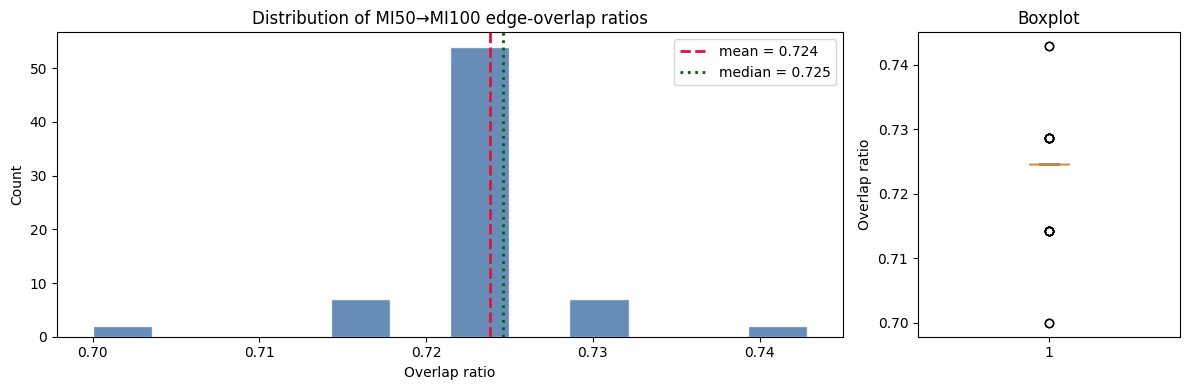

count    72.000000
mean      0.723835
std       0.006155
min       0.700000
25%       0.724638
50%       0.724638
75%       0.724638
max       0.742857
Name: ratio, dtype: float64

In [ ]:
# Plot the distribution of overlap ratios between each mi50 best DAG and each mi100 best DAG.

ratio_values = ratios_df["ratio"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [3, 1]})

axes[0].hist(ratio_values, bins=24, color="#4c78a8", edgecolor="white", alpha=0.85)
axes[0].axvline(ratio_values.mean(), color="crimson", linestyle="--", linewidth=2, label=f"mean = {ratio_values.mean():.3f}")
axes[0].axvline(ratio_values.median(), color="darkgreen", linestyle=":", linewidth=2, label=f"median = {ratio_values.median():.3f}")
axes[0].set_title("Distribution of MI50→MI100 edge-overlap ratios")
axes[0].set_xlabel("Overlap ratio")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].boxplot(
    ratio_values,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="#72b7b2", alpha=0.8),
)
axes[1].set_title("Boxplot")
axes[1].set_ylabel("Overlap ratio")

plt.tight_layout()
plt.show()

ratio_values.describe()

In [17]:
# Distribution of ratios

